Density Based spatial clustering of Application with Noise is an unsupervised machine learning alg used for clusterign data pooints based on their density.It's effictive in identifying of library shape and decting outliers(noise).

In [16]:
from sklearn.cluster import DBSCAN
import numpy as np

# Sample data
X = np.array([
    [1, 2], [2, 2], [2, 3],
    [8, 7], [8, 8], [25, 80]
])

# DBSCAN model
dbscan = DBSCAN(eps=3, min_samples=2)
dbscan.fit(X)

# Results
print("Labels:", dbscan.labels_)


Labels: [ 0  0  0  1  1 -1]


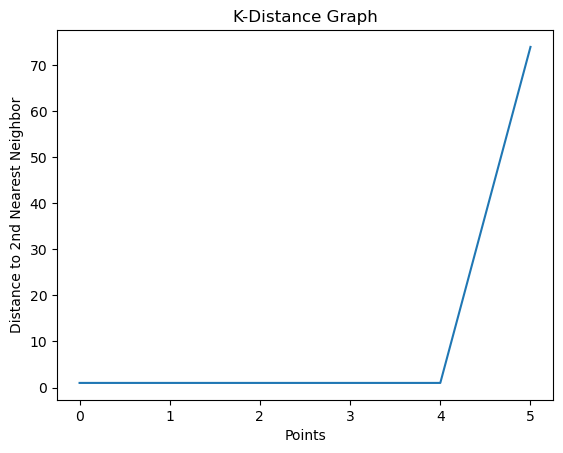

In [18]:
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
import numpy as np

# Sample data
X = np.array([
    [1, 2], [2, 2], [2, 3],
    [8, 7], [8, 8], [25, 80]
])

# Compute the nearest neighbors
neighbors = NearestNeighbors(n_neighbors=2)
neighbors_fit = neighbors.fit(X)
distances, indices = neighbors_fit.kneighbors(X)

# Sort and plot the distances
distances = np.sort(distances[:, 1])
plt.plot(distances)
plt.xlabel('Points')
plt.ylabel('Distance to 2nd Nearest Neighbor')
plt.title('K-Distance Graph')
plt.show()


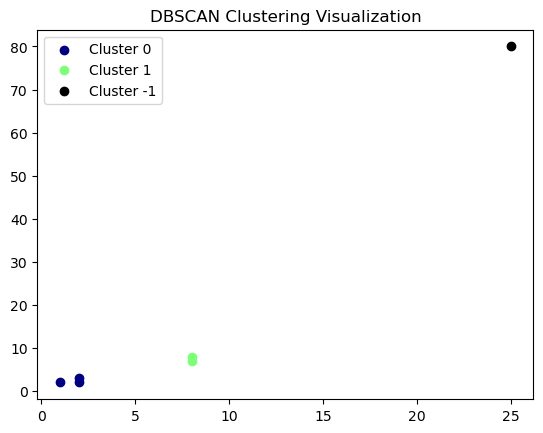

In [20]:
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt

# DBSCAN model with chosen parameters
dbscan = DBSCAN(eps=3, min_samples=2)
dbscan.fit(X)

# Visualizing the clusters
labels = dbscan.labels_
unique_labels = set(labels)

for label in unique_labels:
    # -1 is noise
    color = 'k' if label == -1 else plt.cm.jet(float(label) / max(labels + 1))
    plt.scatter(X[labels == label, 0], X[labels == label, 1], c=[color], label=f'Cluster {label}')

plt.legend()
plt.title('DBSCAN Clustering Visualization')
plt.show()


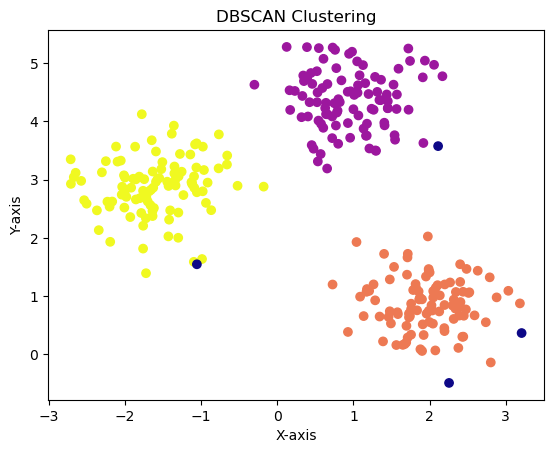

In [44]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_blobs

# Generate sample data
X, _ = make_blobs(n_samples=300, centers=3, cluster_std=0.5, random_state=0)

# Apply DBSCAN
db = DBSCAN(eps=0.5, min_samples=5)
labels = db.fit_predict(X)

# Plotting the clusters
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='plasma')
plt.title('DBSCAN Clustering')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.show()


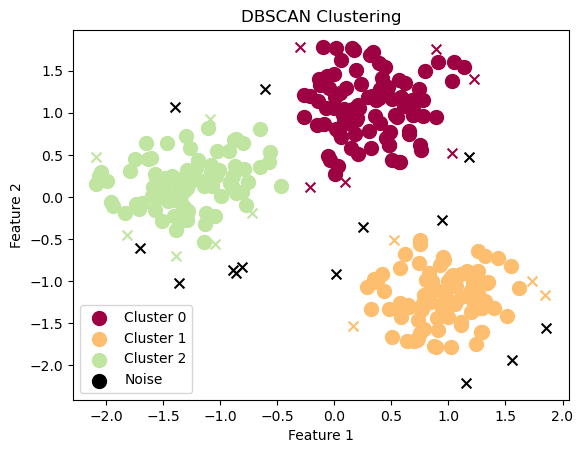

Cluster Labels: [ 0  1  0  2  2  2 -1  0  2  2  1  1  1  0  1  2  0  0  2  1  2  0  1  0
  2  2  0  2  1  1  2  0  0  1  1  2  1 -1  0  1  2  1  0  1  1  2  1 -1
  2  1  2 -1  2  2  1  0  0  2  2  0  1  1  0  2  1  2  0  1  0  1  2  2
  2  2  1  0  1  2  0  0  2  0  1  0  0  0  1  2  0  0  2  1  2  0  1  1
  0  1  2  0  1  2  0  1  0  0  2  0  1  1  0  2  0  0  2  2  0  0  1  1
  1  2  1  1  1  2  1  1  1  2  2  2  0  2  2  1  2  0  2  2  1  0  1  0
  2  2  0  2  2  1  0  2  0  1  2  2  1  1  0  1  0  0  1  0  2  0  0  0
  0  2  1  0  2  1  1 -1  0  1  0  0  1  2  0  0  0  0  1  2  0  2  0  0
  1  1  2  0  1  2  0  2  1  2  0  2  1  2  0  2  0  1  0  0  2  1  1  1
  1  0 -1  1  0 -1  1  1  0  2  2  0 -1  2  0  1  1  0  1  2 -1 -1  0  0
  1  2  2 -1  2  1  2  2  0  1  1  0  1  1  2  0  1  2  0  0  2  0  2  2
 -1  2  0  1  1  1  1  0  0  0  0  0  2  2  1  0  0  1  1 -1  2  1  2  2
  1  1  2  2  2 -1  0  0  2  1  0  0]
Number of clusters: 3
Number of noise points: 14


In [58]:
# Importing necessary libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler

# -----------------------------
# 1. Generate Sample Data
# -----------------------------
X, _ = make_blobs(n_samples=300, centers=3, cluster_std=0.60, random_state=0)

# Standardize the data for better clustering
X = StandardScaler().fit_transform(X)

# -----------------------------
# 2. Apply DBSCAN
# -----------------------------
# Set DBSCAN parameters
dbscan = DBSCAN(eps=0.3, min_samples=5)
dbscan.fit(X)

# Get cluster labels
labels = dbscan.labels_

# -----------------------------
# 3. Visualizing the Clusters
# -----------------------------
# Identify core samples for plotting
core_samples_mask = np.zeros_like(dbscan.labels_, dtype=bool)
core_samples_mask[dbscan.core_sample_indices_] = True

# Unique labels (-1 is for noise)
unique_labels = set(labels)
colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]

# Plotting clusters
for k, col in zip(unique_labels, colors):
    if k == -1:
        # Black for noise
        col = [0, 0, 0, 1]
    
    class_member_mask = (labels == k)
    
    # Plot core points
    xy = X[class_member_mask & core_samples_mask]
    plt.scatter(xy[:, 0], xy[:, 1], c=[col], marker='o', s=100, label=f'Cluster {k}' if k != -1 else 'Noise')
    
    # Plot border points
    xy = X[class_member_mask & ~core_samples_mask]
    plt.scatter(xy[:, 0], xy[:, 1], c=[col], marker='x', s=50)

plt.title('DBSCAN Clustering')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.show()

# -----------------------------
# 4. Print Cluster Information
# -----------------------------
print("Cluster Labels:", labels)
print("Number of clusters:", len(set(labels)) - (1 if -1 in labels else 0))
print("Number of noise points:", list(labels).count(-1))
